In [25]:
# Standard library imports
import os
import sys
import json
import pickle
import random
import re
from glob import glob
from pathlib import Path

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cv2
from tqdm import tqdm
import scipy

# PyTorch imports
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# torchvision imports
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from torchvision.datasets import VisionDataset
import torchvision.transforms as T

# PIL imports
from PIL import Image

import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score
import scipy.stats as stats

In [26]:
from datasets import ISICDataset, HAM10000Dataset, PH2Dataset, BCN20000Dataset

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32

In [28]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# Dataset Preprocessing

In [60]:
artifacts = ["dark_corner",	"hair",	"gel_border","gel_bubble","ruler","ink","patches"]

In [56]:
df = pd.read_csv("/data/healthy-ml/scratch/qixuanj/debiasing-skin/artefacts-annotation/isic_bias.csv", index_col=0)

In [57]:
df

,image,dark_corner,hair,gel_border,gel_bubble,ruler,ink,patches,label,label_string,split_1,split_2,split_3,split_4,split_5
0,ISIC_0000000.JPG,0,0,0,0,0,0,0,0,benign,train,train,train,test,train
1,ISIC_0000001.JPG,0,1,0,1,0,0,0,0,benign,train,train,train,train,test
2,ISIC_0000003.JPG,0,1,0,1,0,0,0,0,benign,train,train,test,train,train
3,ISIC_0000004.JPG,1,1,0,1,1,0,0,1,malignant,train,train,train,test,train
4,ISIC_0000006.JPG,1,0,0,0,0,0,0,0,benign,train,train,train,train,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2589,ISIC_0016068.JPG,1,0,0,1,1,0,0,0,benign,train,test,train,train,train
2590,ISIC_0016069.JPG,1,0,0,0,1,0,0,0,benign,train,train,train,test,train
2591,ISIC_0016070.JPG,1,1,0,1,1,0,0,0,benign,train,train,test,train,train
2592,ISIC_0016071.JPG,0,0,1,0,1,1,0,0,benign,test,train,train,train,train


In [61]:
correlation_matrix = df[artifacts + ['label']].corr()
artifact_label_correlation = correlation_matrix["label"]

# Display correlation with label
print(artifact_label_correlation)

dark_corner    0.083676
hair          -0.077681
gel_border    -0.102704
gel_bubble     0.006752
ruler          0.100417
ink           -0.065187
patches       -0.131947
label          1.000000
Name: label, dtype: float64


In [62]:
display(correlation_matrix)

,dark_corner,hair,gel_border,gel_bubble,ruler,ink,patches,label
dark_corner,1.000000,-0.103374,-0.144011,-0.033379,0.312700,0.081595,0.042584,0.083676
hair,-0.103374,1.000000,-0.073598,-0.036698,-0.191542,-0.144964,0.122731,-0.077681
gel_border,-0.144011,-0.073598,1.000000,-0.236224,0.338354,0.418221,0.227352,-0.102704
gel_bubble,-0.033379,-0.036698,-0.236224,1.000000,-0.172993,-0.046949,-0.242537,0.006752
ruler,0.312700,-0.191542,0.338354,-0.172993,1.000000,0.396242,-0.252100,0.100417
ink,0.081595,-0.144964,0.418221,-0.046949,0.396242,1.000000,-0.122356,-0.065187
patches,0.042584,0.122731,0.227352,-0.242537,-0.252100,-0.122356,1.000000,-0.131947
label,0.083676,-0.077681,-0.102704,0.006752,0.100417,-0.065187,-0.131947,1.000000


In [10]:
from sklearn.model_selection import KFold

In [11]:
# Number of splits
num_splits = 5
kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)

# Assign splits
for i, (train_idx, test_idx) in enumerate(kf.split(df), 1):
    df[f"split_{i}"] = "train"
    df.loc[test_idx, f"split_{i}"] = "test"

In [15]:
# df.to_csv("/data/healthy-ml/scratch/qixuanj/debiasing-skin/artefacts-annotation/isic_bias.csv")

In [16]:
df

,image,dark_corner,hair,gel_border,gel_bubble,ruler,ink,patches,label,label_string,split_1,split_2,split_3,split_4,split_5
0,ISIC_0000000.JPG,0,0,0,0,0,0,0,0,benign,train,train,train,test,train
1,ISIC_0000001.JPG,0,1,0,1,0,0,0,0,benign,train,train,train,train,test
2,ISIC_0000003.JPG,0,1,0,1,0,0,0,0,benign,train,train,test,train,train
3,ISIC_0000004.JPG,1,1,0,1,1,0,0,1,malignant,train,train,train,test,train
4,ISIC_0000006.JPG,1,0,0,0,0,0,0,0,benign,train,train,train,train,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2589,ISIC_0016068.JPG,1,0,0,1,1,0,0,0,benign,train,test,train,train,train
2590,ISIC_0016069.JPG,1,0,0,0,1,0,0,0,benign,train,train,train,test,train
2591,ISIC_0016070.JPG,1,1,0,1,1,0,0,0,benign,train,train,test,train,train
2592,ISIC_0016071.JPG,0,0,1,0,1,1,0,0,benign,test,train,train,train,train


# ISIC melanoma classification model

In [46]:
# Define paths
image_dir = "/data/healthy-ml/gobi1/data/ISIC/2018_train_task1-2"
mask_dir = "/data/healthy-ml/gobi1/data/ISIC/2018_train_task1-2_segmentations"

# Create dataset instances for each mode
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]


In [47]:
dataset = ISICDataset(df, image_dir, mask_dir, mode="high_lesion", return_pil= True)

In [48]:
print(len(dataset))

2594


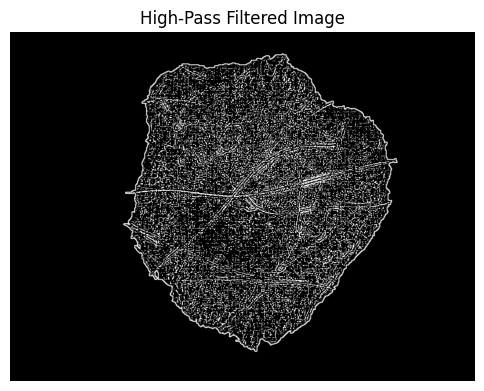

In [117]:
high_pass_img = dataset[2][0]
high_pass_array = np.array(high_pass_img).astype(np.float32)  # Convert to float for scaling

# Normalize for visualization
high_pass_array = (high_pass_array - high_pass_array.min()) / (high_pass_array.max() - high_pass_array.min()) * 255
high_pass_array = high_pass_array.astype(np.uint8)  # Convert back to 8-bit

# Display the image
plt.figure(figsize=(6,6))
plt.imshow(high_pass_array)
plt.axis("off")
plt.title("High-Pass Filtered Image")
plt.show()

In [29]:
dataloader = DataLoader(ISICDataset(df, image_dir, mask_dir, mode="whole"), batch_size=16, shuffle=True)

In [134]:
# Device configuration

# Training hyperparameters
num_epochs = 10  # Adjust as needed
learning_rate = 1e-4
batch_size = 32


# Select dataset mode (e.g., "whole", "lesion", etc.)
dataset_mode = "whole"  # Change this to your desired mode

# Create a directory to save models
save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{dataset_mode}"
os.makedirs(save_dir, exist_ok=True)

# Load dataset for this split
full_dataset = ISICDataset(df, image_dir, mask_dir, transform=transform, mode=dataset_mode, return_pil=False)

# Loop through each split (split_1 to split_5)
for split in range(1, 6):
    print(f"Training on {dataset_mode} - Split {split}")

    train_indices = df[df[f"split_{split}"] == "train"].index.tolist()
    test_indices = df[df[f"split_{split}"] == "test"].index.tolist()

    # Create subset datasets
    train_dataset = Subset(full_dataset, train_indices)
    test_dataset = Subset(full_dataset, test_indices)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Load pre-trained ResNet50
    model = models.resnet50(pretrained=True)
    
    # Modify the final layer for binary classification
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 1),
        nn.Sigmoid()
    )
    
    model = model.to(device)

    # Define loss function and optimizer
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        print(f"Starting epoch {epoch}")
        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # Ensure labels are (batch, 1)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Save the trained model for this split
    model_path = f"{save_dir}/resnet50_split_{split}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

print("Training completed for all splits!")

Training on whole - Split 1
Starting epoch 0


100%|███████████████████████████████████████████████████████████████████| 65/65 [03:35<00:00,  3.32s/it]


Epoch [1/10], Loss: 0.4486
Starting epoch 1


100%|███████████████████████████████████████████████████████████████████| 65/65 [03:28<00:00,  3.20s/it]


Epoch [2/10], Loss: 0.2302
Starting epoch 2


...

Epoch [8/10], Loss: 0.0270
Starting epoch 8


100%|███████████████████████████████████████████████████████████████████| 65/65 [03:43<00:00,  3.43s/it]


Epoch [9/10], Loss: 0.0378
Starting epoch 9


100%|███████████████████████████████████████████████████████████████████| 65/65 [03:56<00:00,  3.64s/it]


Epoch [10/10], Loss: 0.0218
Model saved to /mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/whole/resnet50_split_5.pth
Training completed for all splits!


In [ ]:
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


In [9]:
dataset_mode = "high_whole"  # Change this as needed

all_metrics = {
    "AUROC": [],
    "Accuracy": [],
    "Recall": [],
    "Precision": []
}


# Directory containing saved models
save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{dataset_mode}"

# Load dataset
full_dataset = ISICDataset(df, image_dir, mask_dir, transform=transform, mode=dataset_mode, return_pil=False)

store_preds = {}
store_labels = {}

# Loop through each split
for split in range(1, 6):
    print(f"Evaluating {dataset_mode} - Split {split}")

    # Get test indices
    test_indices = df[df[f"split_{split}"] == "test"].index.tolist()

    # Create test dataset and DataLoader
    test_dataset = Subset(full_dataset, test_indices)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Load model
    model = models.resnet50(pretrained=False)  # Load model architecture
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 1),
        nn.Sigmoid()
    )
    
    model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
    model = model.to(device)
    model.eval()

    # Lists to store predictions and labels
    all_preds = []
    all_labels = []

    # Evaluation loop
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating Split {split}"):
            images = images.to(device)
            labels = labels.cpu().numpy()  # Convert labels to NumPy array

            outputs = model(images).cpu().numpy()  # Get model predictions
            preds = outputs.flatten()  # Flatten predictions

            all_preds.extend(preds)
            all_labels.extend(labels)

    # Convert lists to NumPy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    auroc = roc_auc_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds >= 0.5)
    recall = recall_score(all_labels, all_preds >= 0.5)
    precision = precision_score(all_labels, all_preds >= 0.5)

    # Store metrics
    all_metrics["AUROC"].append(auroc)
    all_metrics["Accuracy"].append(acc)
    all_metrics["Recall"].append(recall)
    all_metrics["Precision"].append(precision)

    store_preds[split] = all_preds 
    store_labels[split] = all_labels

    print(f"Split {split} - AUROC: {auroc:.4f}, Accuracy: {acc:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

# Compute mean metrics across splits
mean_metrics = {metric: np.mean(values) for metric, values in all_metrics.items()}

# Print final results
print("\n===== Final Evaluation Results =====")
for metric, mean_value in mean_metrics.items():
    print(f"Mean {metric}: {mean_value:.4f}")

Evaluating high_whole - Split 1


NameError: name 'Subset' is not defined

In [165]:
with open (f"{save_dir}/all_metrics.pkl", "wb") as f: 
    pickle.dump(all_metrics, f)

In [166]:
with open (f"{save_dir}/store_preds.pkl", "wb") as f: 
    pickle.dump(store_preds, f)

In [167]:
with open (f"{save_dir}/store_labels.pkl", "wb") as f: 
    pickle.dump(store_labels, f)

In [ ]:
with open (f"{save_dir}/all_metrics.pkl", "rb") as f: 
    all_metrics = pickle.load(f)

In [71]:
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]

mean_results = {}

# Iterate through each artifact and compute mean metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/{mode}"
    with open(f"{save_dir}/all_metrics_ham10000.pkl", "rb") as f:
        results_dict = pickle.load(f)

    # Compute mean for each metric
    mean_results[mode] = {metric: np.mean(values) for metric, values in results_dict.items()}

# Convert to DataFrame for easy viewing
df_mean_results = pd.DataFrame.from_dict(mean_results, orient="index")

In [72]:
df_mean_results 

,AUROC,Accuracy,Recall,Precision
whole,0.637594,0.787006,0.260755,0.419450
lesion,0.624038,0.754472,0.306166,0.362418
background,0.504582,0.745289,0.167883,0.292545
bbox,0.513589,0.745085,0.190004,0.279632
bbox70,0.570072,0.712550,0.322573,0.295550
bbox90,0.432715,0.557938,0.272704,0.150154
high_whole,0.608696,0.671158,0.359026,0.281024
low_whole,0.721330,0.724319,0.487893,0.385155
high_lesion,0.624515,0.773079,0.178659,0.336648
low_lesion,0.610346,0.742197,0.210941,0.387296


In [28]:
error_bounds = {}
confidence_level = 0.95
z_value = stats.norm.ppf(0.5 + confidence_level / 2)  # 1.96 for 95% CI

for metric, values in results_dict.items():
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)  # Sample standard deviation
    ci = z_value * (std_val / np.sqrt(len(values)))  # 95% CI

    error_bounds[metric] = {
        "Mean": mean_val,
        "Std": std_val,
        "Lower Bound": mean_val - ci,
        "Upper Bound": mean_val + ci
    }

# Convert to DataFrame for easy visualization
df_error_bounds = pd.DataFrame.from_dict(error_bounds, orient="index")

In [29]:
df_error_bounds

,Mean,Std,Lower Bound,Upper Bound
AUROC,0.703990,0.034504,0.673746,0.734234
Accuracy,0.791071,0.028745,0.765875,0.816267
Recall,0.194554,0.073597,0.130045,0.259063
Precision,0.473116,0.106455,0.379806,0.566426


In [76]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
import os

# Define dataset modes
dataset_modes = [
    "whole", "lesion", "background", "bbox", "bbox70", "bbox90",
    "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"
]

# Dictionary to store results
results_summary = {}

# Confidence level for error bounds
confidence_level = 0.95
z_value = stats.norm.ppf(0.5 + confidence_level / 2)  # 1.96 for 95% CI

# Iterate through each dataset mode and compute metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/{mode}"
    file_path = f"{save_dir}/all_metrics_ham10000.pkl"
    
    if not os.path.exists(file_path):
        print(f"Skipping {mode}: File not found.")
        continue

    try:
        with open(file_path, "rb") as f:
            results_dict = pickle.load(f)

        # Compute only AUROC Std
        if "AUROC" in results_dict:
            values = results_dict["AUROC"]
            std_val = np.std(values, ddof=1)  # Sample standard deviation
            results_summary[mode] = {"AUROC Std": std_val}

    except Exception as e:
        print(f"Error processing {mode}: {e}")

# Convert results to a DataFrame if there is valid data
df_results = pd.DataFrame.from_dict(results_summary, orient="index")

# Display the DataFrame
df_results.round(3)

,AUROC Std
whole,0.064
lesion,0.034
background,0.067
bbox,0.041
bbox70,0.016
bbox90,0.030
high_whole,0.025
low_whole,0.047
high_lesion,0.049
low_lesion,0.079


# Eval on HAM10000

In [240]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, image_dir, mask_dir, transform=None, mode="whole", return_pil=False):
        """
        Args:
            df (pd.DataFrame): DataFrame containing image names and labels.
            image_dir (str): Directory containing original images.
            mask_dir (str): Directory containing ground truth segmentations.
            transform (callable, optional): Optional transform to apply to images.
            mode (str): One of "whole", "lesion", "background", "bbox", "bbox70", 
                        "bbox90", "high_whole", "low_whole", "high_lesion",
                        "low_lesion", "high_background", "low_background".
        """
        self.df = df
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.return_pil = return_pil
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image
        img_name = self.df.iloc[idx]['image_id']
        label = self.df.iloc[idx]['label']
        
        img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        mask_path = os.path.join(self.mask_dir, f"{img_name}_segmentation.png")
        
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # Load segmentation mask
        
        # Ensure images and masks are the same size
        if image.shape[:2] != mask.shape:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        
        # Binarize mask
        mask = (mask > 0).astype(np.uint8)
        
        if self.mode == "whole":
            processed_image = image
        
        elif self.mode == "lesion":
            processed_image = image * mask[:, :, np.newaxis]

        elif self.mode == "background":
            processed_image = image * (1 - mask[:, :, np.newaxis])

        elif self.mode in ["bbox", "bbox70", "bbox90"]:
            # Compute bounding box around lesion
            y_idxs, x_idxs = np.where(mask > 0)
            if len(y_idxs) == 0 or len(x_idxs) == 0:  # If no lesion
                processed_image = image * 0  # Blackout image
            else:
                y_min, y_max = y_idxs.min(), y_idxs.max()
                x_min, x_max = x_idxs.min(), x_idxs.max()
                
                # Compute the original bbox (for `bbox`)
                if self.mode == "bbox":
                    processed_image = image.copy()
                    cv2.rectangle(processed_image, (x_min, y_min), (x_max, y_max), (0, 0, 0), thickness=-1)

                # Expand bbox for bbox70 and bbox90
                else:
                    expand_ratio = 0.7 if self.mode == "bbox70" else 0.9

                    img_h, img_w = image.shape[:2]
                    bbox_h = y_max - y_min
                    bbox_w = x_max - x_min

                    # Calculate expansion to reach desired percentage of total image
                    target_area = expand_ratio * img_h * img_w
                    bbox_center_y, bbox_center_x = (y_min + y_max) // 2, (x_min + x_max) // 2
                    
                    # Compute new bbox size
                    new_bbox_h = int(np.sqrt(target_area * (bbox_h / bbox_w)))  # Keep aspect ratio
                    new_bbox_w = int(np.sqrt(target_area * (bbox_w / bbox_h)))

                    # Ensure it fits within image boundaries
                    y_min = max(0, bbox_center_y - new_bbox_h // 2)
                    y_max = min(img_h, bbox_center_y + new_bbox_h // 2)
                    x_min = max(0, bbox_center_x - new_bbox_w // 2)
                    x_max = min(img_w, bbox_center_x + new_bbox_w // 2)

                    processed_image = image.copy()
                    cv2.rectangle(processed_image, (x_min, y_min), (x_max, y_max), (0, 0, 0), thickness=-1)

        elif self.mode.startswith("high_") or self.mode.startswith("low_"):
            base_image = None

            if "whole" in self.mode:
                base_image = image
            elif "lesion" in self.mode:
                base_image = image * mask[:, :, np.newaxis]
            elif "background" in self.mode:
                base_image = image * (1 - mask[:, :, np.newaxis])

            if base_image is not None:
                if "high_" in self.mode:
                    # processed_image = high_pass_filter(base_image)
                    processed_image = high_pass_filter(base_image, sigma=3, grayscale=True)
                else:
                    processed_image = low_pass_filter(base_image, sigma=3)
                    
        if self.return_pil:
            processed_image = Image.fromarray(processed_image.astype(np.uint8))
        else:
            if self.transform: 
                processed_image = Image.fromarray(processed_image)
                processed_image = self.transform(processed_image)
        label = torch.tensor(label, dtype=torch.long)
        
        return processed_image, label

# Define paths
image_dir = "/data/healthy-ml/gobi1/data/ham10000/HAM10000_images"
mask_dir = "/data/healthy-ml/gobi1/data/ham10000/HAM10000_segmentations"

# Create dataset instances for each mode
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]

In [24]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/HAM10000_metadata_with_objects.csv", index_col=0)

In [25]:
print(len(df))

10015


In [216]:
dataset_mode = "low_whole"
full_dataset = HAM10000Dataset(df, image_dir, mask_dir, transform=transform, mode=dataset_mode, return_pil=True)

In [246]:
dataset_mode = "bbox90"  # Change this as needed

all_metrics = {
    "AUROC": [],
    "Accuracy": [],
    "Recall": [],
    "Precision": []
}

# Directory containing saved models (ISIC models)
save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{dataset_mode}"

# Load dataset
full_dataset = HAM10000Dataset(df, image_dir, mask_dir, transform=transform, mode=dataset_mode, return_pil=False)

store_preds = {}
store_labels = {}

# Loop through each split
for split in range(1, 6):
    print(f"Evaluating {dataset_mode} - Split {split}")

    # Get test indices
    test_indices = df[df[f"split_{split}"] == "test"].index.tolist()

    # Create test dataset and DataLoader
    test_dataset = Subset(full_dataset, test_indices)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Load model
    model = models.resnet50(pretrained=False)  # Load model architecture
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 1),
        nn.Sigmoid()
    )
    
    model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
    model = model.to(device)
    model.eval()

    # Lists to store predictions and labels
    all_preds = []
    all_labels = []

    # Evaluation loop
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating Split {split}"):
            images = images.to(device)
            labels = labels.cpu().numpy()  # Convert labels to NumPy array

            outputs = model(images).cpu().numpy()  # Get model predictions
            preds = outputs.flatten()  # Flatten predictions

            all_preds.extend(preds)
            all_labels.extend(labels)

    # Convert lists to NumPy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    auroc = roc_auc_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds >= 0.5)
    recall = recall_score(all_labels, all_preds >= 0.5)
    precision = precision_score(all_labels, all_preds >= 0.5)

    # Store metrics
    all_metrics["AUROC"].append(auroc)
    all_metrics["Accuracy"].append(acc)
    all_metrics["Recall"].append(recall)
    all_metrics["Precision"].append(precision)

    store_preds[split] = all_preds 
    store_labels[split] = all_labels

    print(f"Split {split} - AUROC: {auroc:.4f}, Accuracy: {acc:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

# Compute mean metrics across splits
mean_metrics = {metric: np.mean(values) for metric, values in all_metrics.items()}

# Print final results
print("\n===== Final Evaluation Results =====")
for metric, mean_value in mean_metrics.items():
    print(f"Mean {metric}: {mean_value:.4f}")

Evaluating bbox90 - Split 1


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_2018114/1503335186.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release,

Split 1 - AUROC: 0.5988, Accuracy: 0.7799, Recall: 0.1057, Precision: 0.3037
Evaluating bbox90 - Split 2


/tmp/ipykernel_2018114/1503335186.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 2 - AUROC: 0.6193, Accuracy: 0.7535, Recall: 0.1659, Precision: 0.3091
Evaluating bbox90 - Split 3


...

Split 3 - AUROC: 0.6083, Accuracy: 0.7250, Recall: 0.2964, Precision: 0.2926
Evaluating bbox90 - Split 4


/tmp/ipykernel_2018114/1503335186.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 4 - AUROC: 0.5991, Accuracy: 0.7889, Recall: 0.0771, Precision: 0.3191
Evaluating bbox90 - Split 5


/tmp/ipykernel_2018114/1503335186.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 5 - AUROC: 0.6528, Accuracy: 0.7673, Recall: 0.1662, Precision: 0.2958

===== Final Evaluation Results =====
Mean AUROC: 0.6156
Mean Accuracy: 0.7630
Mean Recall: 0.1623
Mean Precision: 0.3041


In [247]:
with open (f"{save_dir}/all_metrics_ham10000.pkl", "wb") as f: 
    pickle.dump(all_metrics, f)

In [248]:
with open (f"{save_dir}/store_preds_ham10000.pkl", "wb") as f: 
    pickle.dump(store_preds, f)

In [249]:
with open (f"{save_dir}/store_labels_ham10000.pkl", "wb") as f: 
    pickle.dump(store_labels, f)

In [31]:
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]

mean_results = {}

# Iterate through each artifact and compute mean metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{mode}"
    with open(f"{save_dir}/all_metrics_ham10000.pkl", "rb") as f:
        results_dict = pickle.load(f)

    # Compute mean for each metric
    mean_results[mode] = {metric: np.mean(values) for metric, values in results_dict.items()}

# Convert to DataFrame for easy viewing
df_mean_results = pd.DataFrame.from_dict(mean_results, orient="index")

In [32]:
df_mean_results

,AUROC,Accuracy,Recall,Precision
whole,0.720609,0.778423,0.450695,0.441282
lesion,0.718990,0.780514,0.380189,0.457143
background,0.714345,0.751074,0.476386,0.406245
bbox,0.687477,0.785907,0.288412,0.438709
bbox70,0.685576,0.777722,0.261631,0.394621
bbox90,0.615644,0.762951,0.162253,0.304068
high_whole,0.307096,0.803518,0.000000,0.000000
low_whole,0.740783,0.772736,0.426498,0.471738
high_lesion,0.574886,0.650200,0.249356,0.048303
low_lesion,0.685456,0.654544,0.604525,0.314867


# Train on PH2

In [38]:
from sklearn.model_selection import train_test_split

In [42]:
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"

# Create dataset instances for each mode
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", 
                "low_lesion", "high_background", "low_background"
]

In [46]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)

In [48]:
num_epochs = 10  # Adjust as needed
learning_rate = 1e-4
batch_size = 32

for dataset_mode in dataset_modes: 
    # Create a directory to save models
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/{dataset_mode}"
    os.makedirs(save_dir, exist_ok=True)

    print(dataset_mode)
    full_dataset = PH2Dataset(df, image_dir, transform=transform, mode=dataset_mode, return_pil=False)

    for split in range(1, 6):
        print(f"Training on {dataset_mode} - Split {split}")
    
        train_indices = df[df[f"split_{split}"] == "train"].index.tolist()
        test_indices = df[df[f"split_{split}"] == "test"].index.tolist()
    
        # Create subset datasets
        train_dataset = Subset(full_dataset, train_indices)
        test_dataset = Subset(full_dataset, test_indices)
    
        # Create DataLoaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model = models.resnet50(pretrained=True)
        # Modify the final layer for binary classification
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 1),
            nn.Sigmoid()
        )
        model = model.to(device)
    
        # Define loss function and optimizer
        criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            
            print(f"Starting epoch {epoch}")
            for images, labels in tqdm(train_loader):
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)  # Ensure labels are (batch, 1)
    
                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)
    
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                running_loss += loss.item()
    
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

        # Save the trained model for this split
        model_path = f"{save_dir}/resnet50_split{split}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")

print("Training completed for all modes!")

whole
Training on whole - Split 1


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting epoch 0


100%|█████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.51s/it]


Epoch [1/10], Loss: 0.6359
Starting epoch 1


...

Epoch [8/10], Loss: 0.0081
Starting epoch 8


100%|█████████████████████████████████████████████████████████████████████| 5/5 [00:10<00:00,  2.10s/it]


Epoch [9/10], Loss: 0.0059
Starting epoch 9


100%|█████████████████████████████████████████████████████████████████████| 5/5 [00:10<00:00,  2.11s/it]


Epoch [10/10], Loss: 0.0049
Model saved to /mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/low_background/resnet50_split5.pth
Training completed for all modes!


# Eval on PH2

In [49]:
# Define paths
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"

# Create dataset instances for each mode
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", 
                "low_lesion", "high_background", "low_background"
]

In [50]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)

In [12]:
# dataset_mode = "high_whole"
# full_dataset = PH2Dataset(df, image_dir, transform=transform, mode=dataset_mode, return_pil=True)

In [52]:
for dataset_mode in dataset_modes:
    all_metrics = {
        "AUROC": [],
        "Accuracy": [],
        "Recall": [],
        "Precision": []
    }
    
    # Directory containing saved models (ISIC models)
    # save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{dataset_mode}"
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/{dataset_mode}"
    
    # Load dataset
    full_dataset = PH2Dataset(df, image_dir, transform=transform, mode=dataset_mode, return_pil=False)
    
    store_preds = {}
    store_labels = {}

    # Loop through each split
    for split in range(1, 6):
        test_indices = df[df[f"split_{split}"] == "test"].index.tolist()
        test_dataset = Subset(full_dataset, test_indices)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Evaluating {dataset_mode} - Split {split}")
        model = models.resnet50(pretrained=False)  # Load model architecture
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 1),
            nn.Sigmoid()
        )
        
        model.load_state_dict(torch.load(f"{save_dir}/resnet50_split{split}.pth"))
        model = model.to(device)
        model.eval()
    
        # Lists to store predictions and labels
        all_preds = []
        all_labels = []

        # Evaluation loop
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Evaluating Split {split}"):
                images = images.to(device)
                labels = labels.cpu().numpy()  # Convert labels to NumPy array
    
                outputs = model(images).cpu().numpy()  # Get model predictions
                preds = outputs.flatten()  # Flatten predictions
    
                all_preds.extend(preds)
                all_labels.extend(labels)
    
        # Convert lists to NumPy arrays
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
    
        # Compute metrics
        auroc = roc_auc_score(all_labels, all_preds)
        acc = accuracy_score(all_labels, all_preds >= 0.5)
        recall = recall_score(all_labels, all_preds >= 0.5)
        precision = precision_score(all_labels, all_preds >= 0.5)
    
        # Store metrics
        all_metrics["AUROC"].append(auroc)
        all_metrics["Accuracy"].append(acc)
        all_metrics["Recall"].append(recall)
        all_metrics["Precision"].append(precision)
    
        store_preds[split] = all_preds 
        store_labels[split] = all_labels
    
        print(f"Split {split} - AUROC: {auroc:.4f}, Accuracy: {acc:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
    
    # Compute mean metrics across splits
    mean_metrics = {metric: np.mean(values) for metric, values in all_metrics.items()}
    
    # Print final results
    print("\n===== Final Evaluation Results =====")
    for metric, mean_value in mean_metrics.items():
        print(f"Mean {metric}: {mean_value:.4f}")
        
    with open (f"{save_dir}/all_metrics_ph2_test.pkl", "wb") as f: 
        pickle.dump(all_metrics, f)
    with open (f"{save_dir}/store_preds_ph2_test.pkl", "wb") as f: 
        pickle.dump(store_preds, f)
    with open (f"{save_dir}/store_labels_ph2_test.pkl", "wb") as f: 
        pickle.dump(store_labels, f)

Evaluating whole - Split 1


/tmp/ipykernel_23281/4156090961.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split{split}.pth"))
Evaluating Sp

Split 1 - AUROC: 0.9773, Accuracy: 0.9024, Recall: 0.6250, Precision: 0.8333
Evaluating whole - Split 2


/tmp/ipykernel_23281/4156090961.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split{split}.pth"))
Evaluating Sp

Split 2 - AUROC: 0.9931, Accuracy: 0.9512, Recall: 0.8889, Precision: 0.8889
Evaluating whole - Split 3


...

Split 3 - AUROC: 0.8908, Accuracy: 0.9024, Recall: 0.5714, Precision: 0.8000
Evaluating low_background - Split 4


/tmp/ipykernel_23281/4156090961.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split{split}.pth"))
Evaluating Sp

Split 4 - AUROC: 0.7955, Accuracy: 0.8537, Recall: 0.3750, Precision: 0.7500
Evaluating low_background - Split 5


/tmp/ipykernel_23281/4156090961.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split{split}.pth"))
Evaluating Sp

Split 5 - AUROC: 0.8781, Accuracy: 0.9250, Recall: 0.7778, Precision: 0.8750

===== Final Evaluation Results =====
Mean AUROC: 0.8902
Mean Accuracy: 0.8972
Mean Recall: 0.5560
Mean Precision: 0.8850


In [33]:
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90", 
                "high_whole", "high_lesion", "high_background", "low_whole", "low_lesion", "low_background"]

mean_results = {}

# Iterate through each artifact and compute mean metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{mode}"
    with open(f"{save_dir}/all_metrics_ph2.pkl", "rb") as f:
        results_dict = pickle.load(f)

    # Compute mean for each metric
    mean_results[mode] = {metric: np.mean(values) for metric, values in results_dict.items()}

# Convert to DataFrame for easy viewing
df_mean_results = pd.DataFrame.from_dict(mean_results, orient="index")

In [34]:
df_mean_results

,AUROC,Accuracy,Recall,Precision
whole,0.857500,0.865,0.430,0.792274
lesion,0.817656,0.820,0.475,0.576500
background,0.777094,0.728,0.615,0.408344
bbox,0.821187,0.778,0.270,0.466696
bbox70,0.804937,0.844,0.350,0.754617
bbox90,0.679281,0.783,0.225,0.560654
high_whole,0.442094,0.799,0.000,0.000000
high_lesion,0.747773,0.655,0.275,0.300000
high_background,0.501602,0.800,0.000,0.000000
low_whole,0.856406,0.835,0.475,0.729951


In [53]:
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90", 
                "high_whole", "high_lesion", "high_background", "low_whole", "low_lesion", "low_background"]

mean_results = {}

# Iterate through each artifact and compute mean metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers_ph2/{mode}"
    with open(f"{save_dir}/all_metrics_ph2_test.pkl", "rb") as f:
        results_dict = pickle.load(f)

    # Compute mean for each metric
    mean_results[mode] = {metric: np.mean(values) for metric, values in results_dict.items()}

# Convert to DataFrame for easy viewing
df_mean_results = pd.DataFrame.from_dict(mean_results, orient="index")

In [54]:
df_mean_results

,AUROC,Accuracy,Recall,Precision
whole,0.974996,0.911707,0.672619,0.860000
lesion,0.952070,0.926463,0.700397,0.908333
background,0.884146,0.902073,0.672619,0.789286
bbox,0.879585,0.906951,0.678968,0.833333
bbox70,0.845242,0.843415,0.530159,0.650159
bbox90,0.864772,0.853171,0.357143,0.786667
high_whole,0.903429,0.867439,0.624603,0.682778
high_lesion,0.925458,0.862927,0.719841,0.650144
high_background,0.876683,0.897195,0.622619,0.809286
low_whole,0.935056,0.921585,0.772619,0.816667


# BCN20000 Eval

In [320]:
class BCN20000Dataset(Dataset):
    def __init__(self, df, image_dir, transform=None, mode="whole", return_pil=False):
        """
        Args:
            df (pd.DataFrame): DataFrame containing image names and labels.
            image_dir (str): Directory containing original images.
            mask_dir (str): Directory containing ground truth segmentations.
            transform (callable, optional): Optional transform to apply to images.
            mode (str): One of "whole", "high_whole", "low_whole"
        """
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
        self.mode = mode
        self.return_pil = return_pil
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image
        img_name = self.df.iloc[idx]['isic_id']
        label = self.df.iloc[idx]['label']
        
        img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        

        if self.mode == "whole":
            processed_image = image

        elif self.mode.startswith("high_") or self.mode.startswith("low_"):
            base_image = None

            if "whole" in self.mode:
                base_image = image
        
            if base_image is not None:
                if "high_" in self.mode:
                    processed_image = high_pass_filter(base_image, sigma=1, grayscale=True)
                else:
                    processed_image = low_pass_filter(base_image, sigma=1)
                    
        if self.return_pil:
            processed_image = Image.fromarray(processed_image.astype(np.uint8))
        else:
            if self.transform: 
                processed_image = Image.fromarray(processed_image)
                processed_image = self.transform(processed_image)
        label = torch.tensor(label, dtype=torch.long)
        
        return processed_image, label

# Define paths
image_dir = "/mnt/scratch-lids/data/bcn20000/"

# Create dataset instances for each mode
dataset_modes = ["whole", "lesion", "background", "bbox", "bbox70", "bbox90",
                 "high_whole", "low_whole", "high_lesion", "low_lesion", "high_background", "low_background"]

In [319]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/bcn20000_metadata.csv", index_col=0)

In [326]:
dataset_mode = "whole"
full_dataset = BCN20000Dataset(df, image_dir, transform=transform, mode=dataset_mode, return_pil=True)

In [327]:
dataset_mode = "whole"  # Change this as needed

all_metrics = {
    "AUROC": [],
    "Accuracy": [],
    "Recall": [],
    "Precision": []
}

# Directory containing saved models (ISIC models)
save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{dataset_mode}"

# Load dataset
full_dataset = BCN20000Dataset(df, image_dir, transform=transform, mode=dataset_mode, return_pil=False)

store_preds = {}
store_labels = {}

# Loop through each split
for split in range(1, 6):
    print(f"Evaluating {dataset_mode} - Split {split}")

    # Get test indices
    test_indices = df[df[f"split_{split}"] == "test"].index.tolist()

    # Create test dataset and DataLoader
    test_dataset = Subset(full_dataset, test_indices)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Load model
    model = models.resnet50(pretrained=False)  # Load model architecture
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 1),
        nn.Sigmoid()
    )
    
    model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
    model = model.to(device)
    model.eval()

    # Lists to store predictions and labels
    all_preds = []
    all_labels = []

    # Evaluation loop
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating Split {split}"):
            images = images.to(device)
            labels = labels.cpu().numpy()  # Convert labels to NumPy array

            outputs = model(images).cpu().numpy()  # Get model predictions
            preds = outputs.flatten()  # Flatten predictions

            all_preds.extend(preds)
            all_labels.extend(labels)

    # Convert lists to NumPy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    auroc = roc_auc_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds >= 0.5)
    recall = recall_score(all_labels, all_preds >= 0.5)
    precision = precision_score(all_labels, all_preds >= 0.5)

    # Store metrics
    all_metrics["AUROC"].append(auroc)
    all_metrics["Accuracy"].append(acc)
    all_metrics["Recall"].append(recall)
    all_metrics["Precision"].append(precision)

    store_preds[split] = all_preds 
    store_labels[split] = all_labels

    print(f"Split {split} - AUROC: {auroc:.4f}, Accuracy: {acc:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

# Compute mean metrics across splits
mean_metrics = {metric: np.mean(values) for metric, values in all_metrics.items()}

# Print final results
print("\n===== Final Evaluation Results =====")
for metric, mean_value in mean_metrics.items():
    print(f"Mean {metric}: {mean_value:.4f}")

Evaluating whole - Split 1


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_2018114/2458305812.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release,

Split 1 - AUROC: 0.5774, Accuracy: 0.5220, Recall: 0.1907, Precision: 0.6747
Evaluating whole - Split 2


/tmp/ipykernel_2018114/2458305812.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 2 - AUROC: 0.6588, Accuracy: 0.5959, Recall: 0.4534, Precision: 0.7048
Evaluating whole - Split 3


...

Split 3 - AUROC: 0.6615, Accuracy: 0.5953, Recall: 0.4320, Precision: 0.6753
Evaluating whole - Split 4


/tmp/ipykernel_2018114/2458305812.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 4 - AUROC: 0.6437, Accuracy: 0.5618, Recall: 0.2652, Precision: 0.7189
Evaluating whole - Split 5


/tmp/ipykernel_2018114/2458305812.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{save_dir}/resnet50_split_{split}.pth"))
Evaluating

Split 5 - AUROC: 0.6997, Accuracy: 0.5835, Recall: 0.2996, Precision: 0.7850

===== Final Evaluation Results =====
Mean AUROC: 0.6482
Mean Accuracy: 0.5717
Mean Recall: 0.3282
Mean Precision: 0.7117


In [328]:
with open (f"{save_dir}/all_metrics_bcn20000.pkl", "wb") as f: 
    pickle.dump(all_metrics, f)

In [329]:
with open (f"{save_dir}/store_preds_bcn20000.pkl", "wb") as f: 
    pickle.dump(store_preds, f)

In [330]:
with open (f"{save_dir}/store_labels_bcn20000.pkl", "wb") as f: 
    pickle.dump(store_labels, f)

In [331]:
dataset_modes = ["whole"]

mean_results = {}

# Iterate through each artifact and compute mean metrics
for mode in dataset_modes:
    save_dir = f"/mnt/scratch-lids/scratch/qixuanj/chil2025/classifiers/{mode}"
    with open(f"{save_dir}/all_metrics_bcn20000.pkl", "rb") as f:
        results_dict = pickle.load(f)

    # Compute mean for each metric
    mean_results[mode] = {metric: np.mean(values) for metric, values in results_dict.items()}

# Convert to DataFrame for easy viewing
df_mean_results = pd.DataFrame.from_dict(mean_results, orient="index")

In [332]:
df_mean_results

,AUROC,Accuracy,Recall,Precision
whole,0.64823,0.57171,0.32818,0.711749


# PH2 Dermoscopic XGBoost model

In [ ]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)

In [335]:
df

,Name,label,Clinical Diagnosis,Histological Diagnosis,Colors,Asymmetry,Pigment Network,Dots/Globules,Streaks,Regression Areas,Blue-Whitish Veil
0,IMD003,0,0,NaN,4,0,T,A,A,A,A
1,IMD009,0,0,NaN,3,0,T,A,A,A,A
2,IMD016,0,0,NaN,3 4,0,T,T,A,A,A
3,IMD022,0,0,NaN,3,0,T,A,A,A,A
4,IMD024,0,0,NaN,3 4,0,T,A,A,A,A
...,...,...,...,...,...,...,...,...,...,...,...
195,IMD424,1,2,Melanoma,3 4 5 6,2,AT,AT,P,A,P
196,IMD425,1,2,Melanoma,3 4 5 6,2,AT,AT,A,P,P
197,IMD426,1,2,Melanoma,3 4,2,AT,A,A,P,A
198,IMD429,1,2,NaN,3 4 5 6,0,AT,A,P,A,P


In [339]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [341]:
# Select relevant columns
features = ['Colors','Asymmetry', 'Pigment Network', 'Dots/Globules', 'Streaks', 'Regression Areas', 'Blue-Whitish Veil']
X = df[features]
y = df['label']

# Encode categorical features
label_encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # Convert all values to strings before encoding
    label_encoders[col] = le

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipykernel_2018114/3576856995.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))  # Convert all values to strings before encoding
/tmp/ipykernel_2018114/3576856995.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))  # Convert all values to strings before encoding
/tmp/ipykernel_2018114/3576856995.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [342]:
# Define and train the XGBoost model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'AUROC: {auroc:.4f}')

Accuracy: 0.9250
Precision: 0.8333
Recall: 0.7143
AUROC: 0.9870


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:58:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


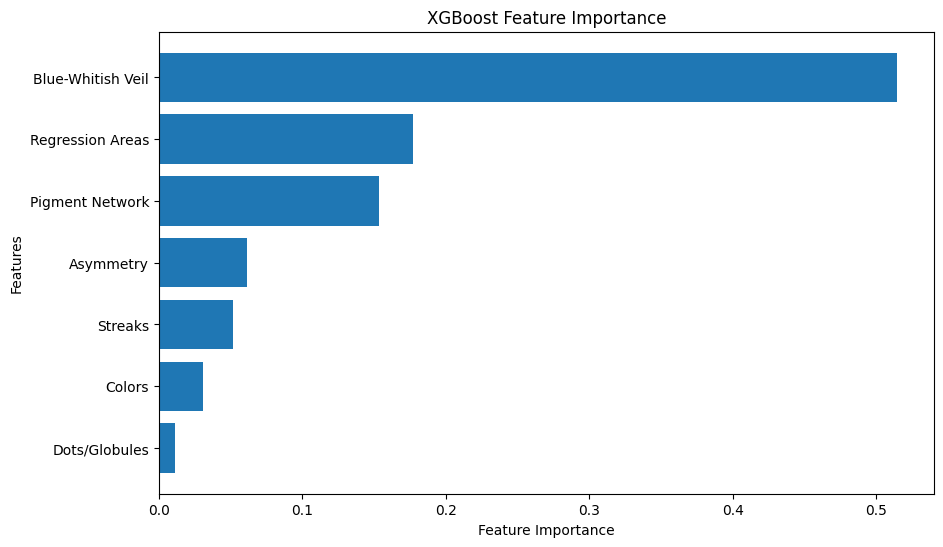

In [343]:
# Feature importance
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Artifact XGBoost model

In [29]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

In [31]:
df = pd.read_csv("/data/healthy-ml/scratch/qixuanj/debiasing-skin/artefacts-annotation/isic_bias.csv", index_col=0)

split 1


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:06:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


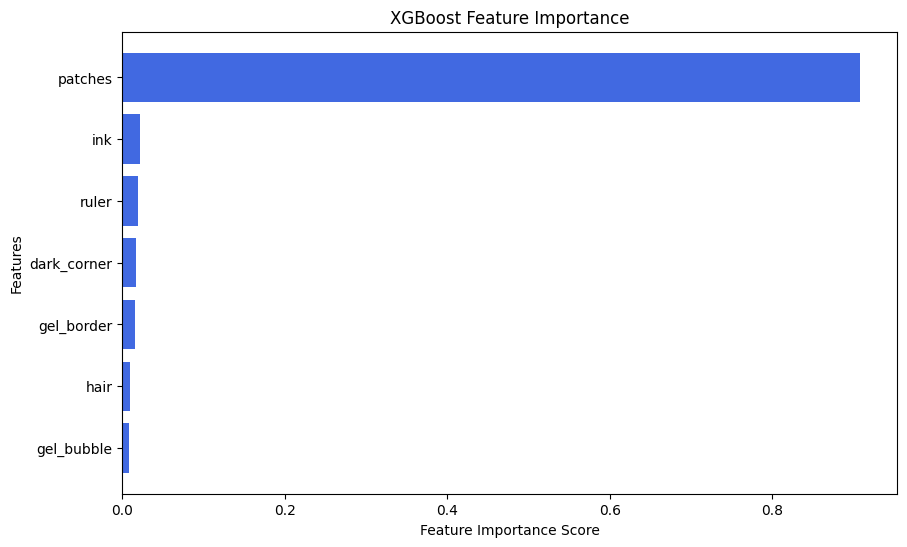

split 2


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:06:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


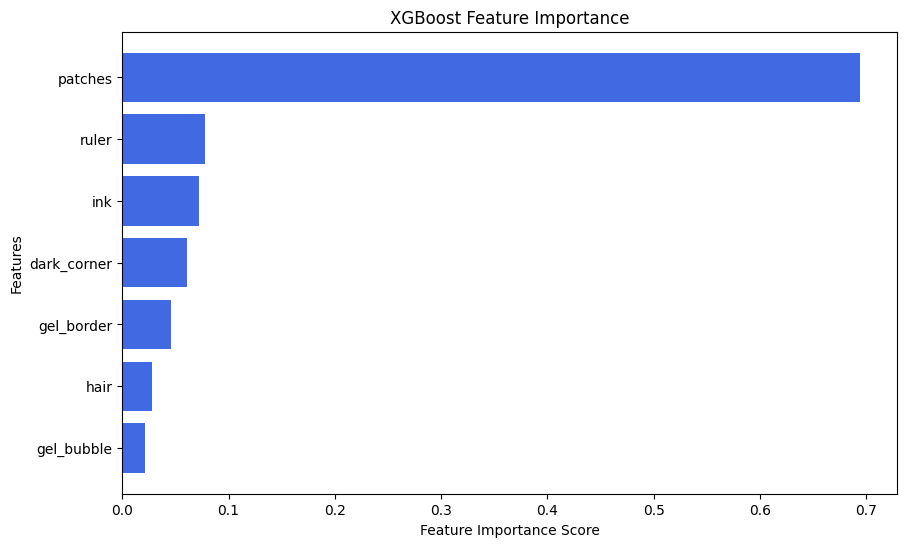

split 3


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:06:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


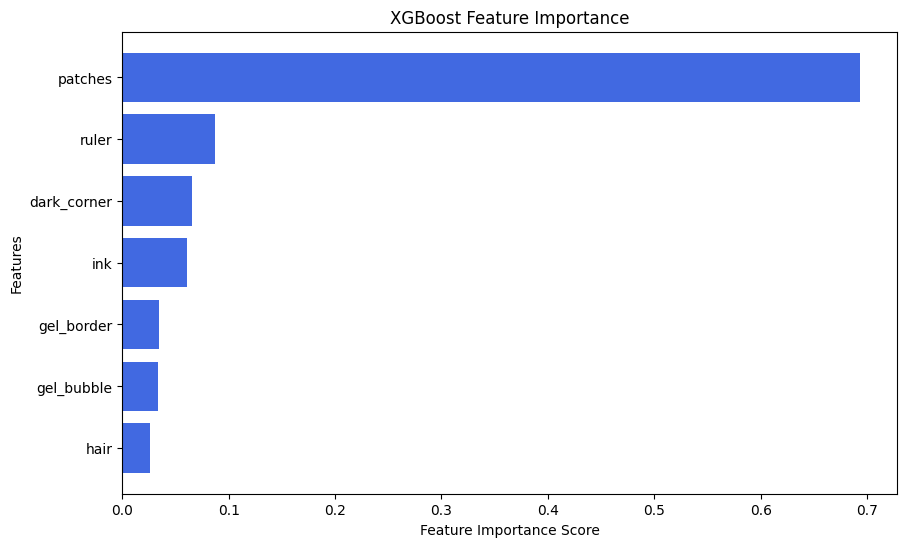

split 4


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:06:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


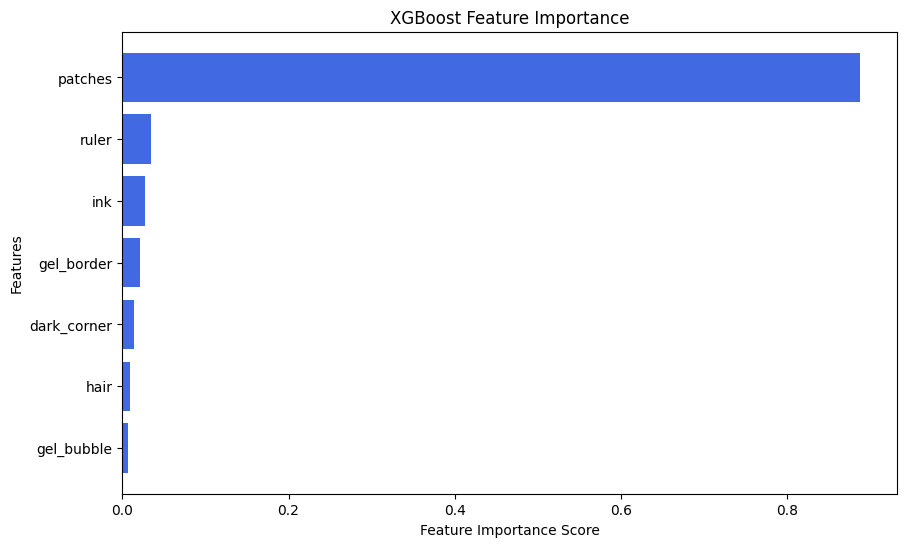

split 5


/data/healthy-ml/scratch/qixuanj/anaconda3/envs/MONET/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:06:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


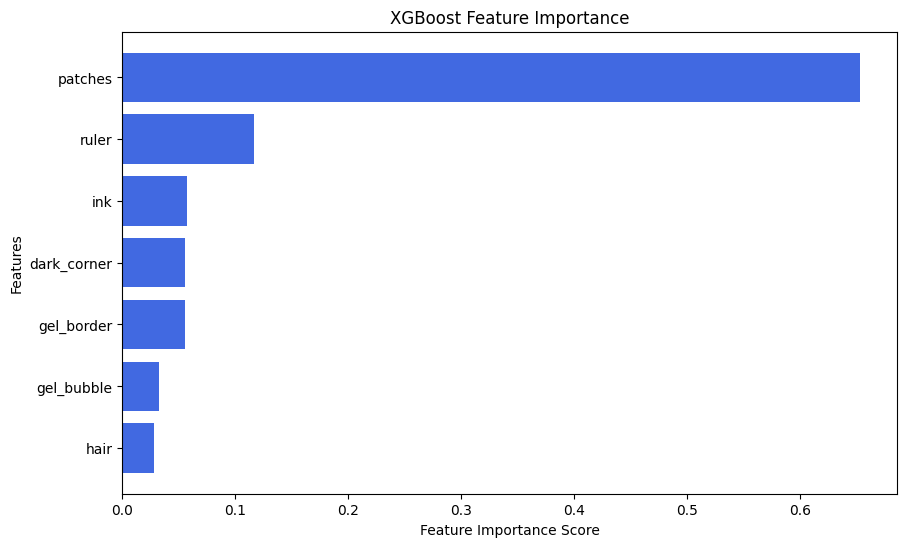

In [37]:
# Load dataset (assuming it's already stored in df)
artifact_columns = ["dark_corner", "hair", "gel_border", "gel_bubble", "ruler", "ink", "patches"]
label_column = "label"

# Store results
results = {}

# Train XGBoost using each split
for i in range(1, 6):  # Loop through split_1 to split_5
    print(f"split {i}")
    train_mask = df[f"split_{i}"] == "train"
    test_mask = df[f"split_{i}"] == "test"

    X_train, y_train = df.loc[train_mask, artifact_columns], df.loc[train_mask, label_column]
    X_test, y_test = df.loc[test_mask, artifact_columns], df.loc[test_mask, label_column]

    # Train an XGBoost model
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    # Store results
    results[f"split_{i}"] = {
        "Accuracy": accuracy,
        "AUROC": auc,
        "Precision": precision,
        "Recall": recall
    }
    # Extract feature importance
    feature_importance = model.feature_importances_
    
    # Sort features by importance
    sorted_indices = np.argsort(feature_importance)[::-1]  # Sort descending
    sorted_importance = feature_importance[sorted_indices]
    sorted_features = np.array(X_train.columns)[sorted_indices]
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features, sorted_importance, color="royalblue")
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title("XGBoost Feature Importance")
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.savefig(f"figs/ISIC_xgboost_feature_importance_split{i}.png", dpi=200)
    plt.show()

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T

In [33]:
results_df

,Accuracy,AUROC,Precision,Recall
split_1,0.795761,0.648436,0.333333,0.009524
split_2,0.805395,0.584123,0.000000,0.000000
split_3,0.807322,0.630036,0.000000,0.000000
split_4,0.770713,0.655788,0.500000,0.008403
split_5,0.814672,0.622604,0.333333,0.021277


In [38]:
results_df.mean(axis=0)

Accuracy     0.798773
AUROC        0.628197
Precision    0.233333
Recall       0.007841
dtype: float64

split 1


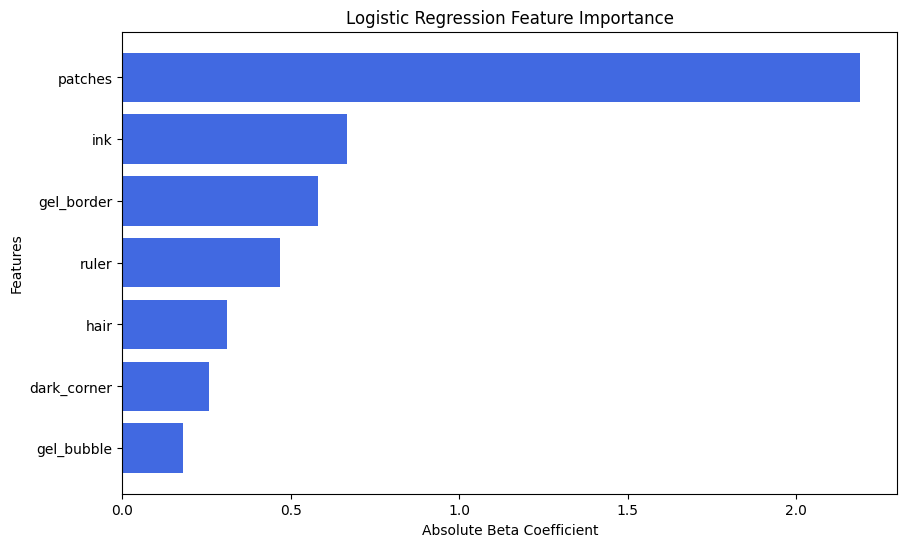

split 2


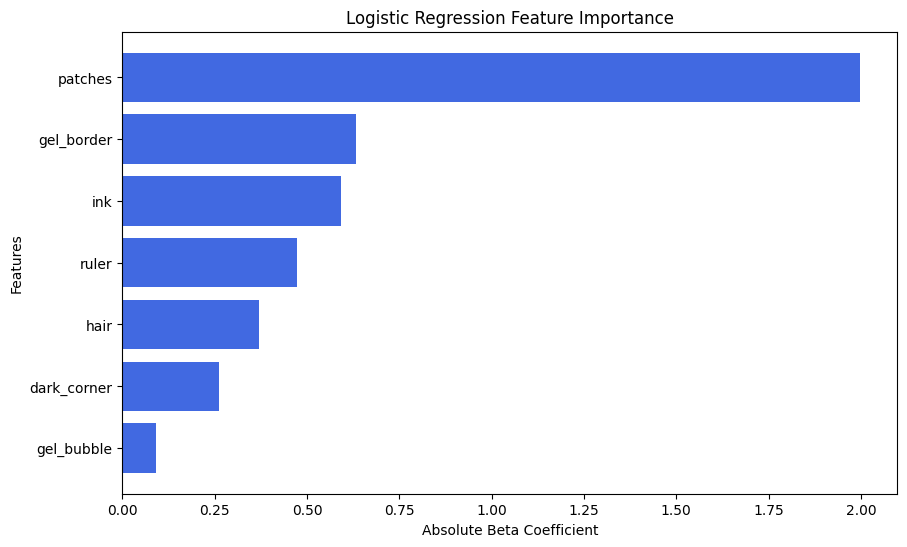

split 3


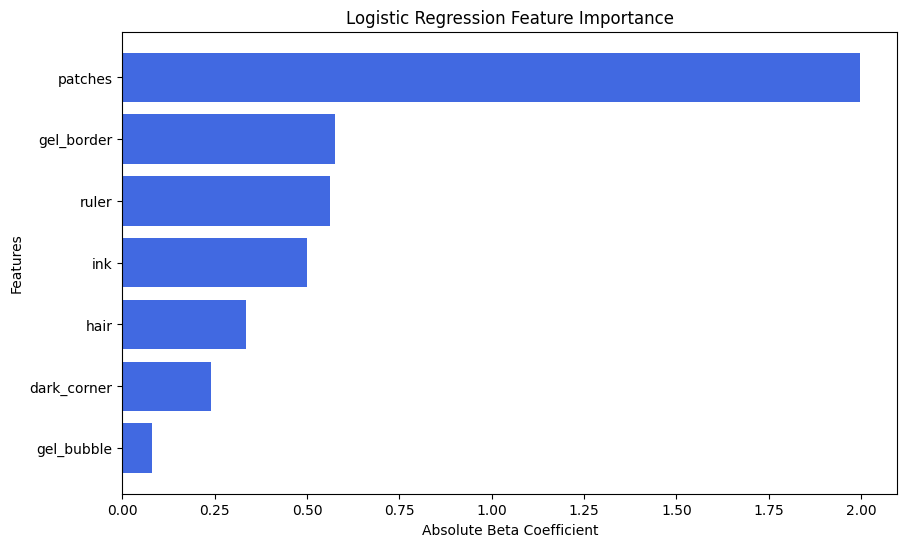

split 4


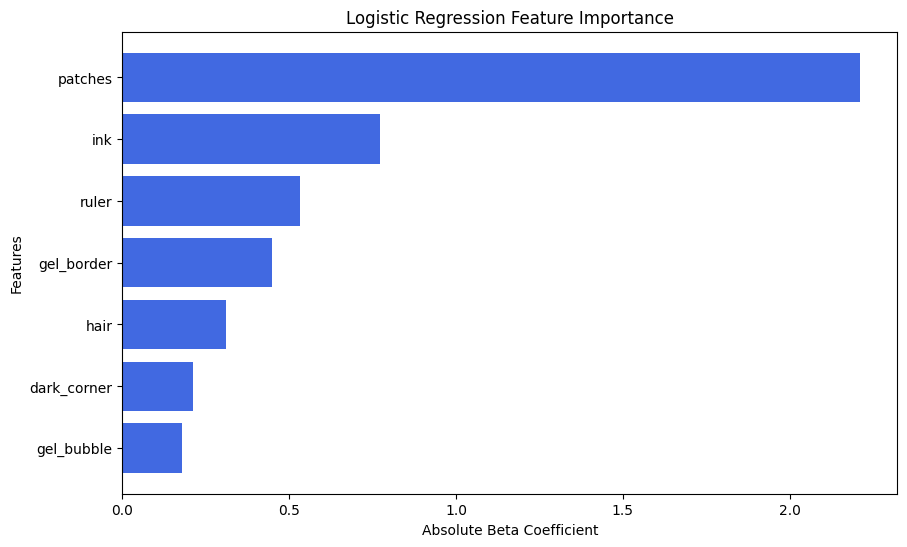

split 5


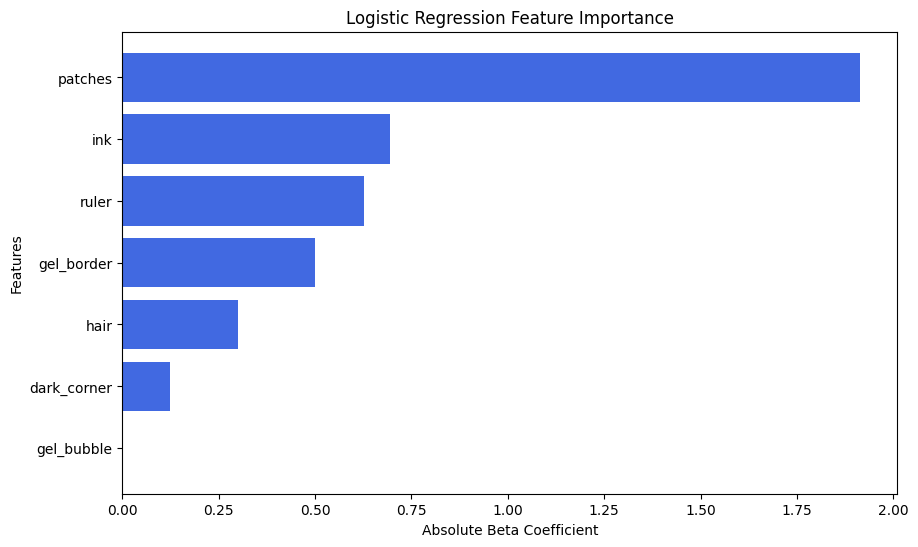

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# Load dataset (assuming it's already stored in df)
artifact_columns = ["dark_corner", "hair", "gel_border", "gel_bubble", "ruler", "ink", "patches"]
label_column = "label"

# Store results
results = {}

# Train Logistic Regression for each split
for i in range(1, 6):  # Loop through split_1 to split_5
    print(f"split {i}")
    
    # Create train and test masks
    train_mask = df[f"split_{i}"] == "train"
    test_mask = df[f"split_{i}"] == "test"

    # Define training and testing data
    X_train, y_train = df.loc[train_mask, artifact_columns], df.loc[train_mask, label_column]
    X_test, y_test = df.loc[test_mask, artifact_columns], df.loc[test_mask, label_column]

    # Train a Logistic Regression model
    model = LogisticRegression(solver='liblinear')  # 'liblinear' works well for small datasets
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probability for class 1

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    # Store results
    results[f"split_{i}"] = {
        "Accuracy": accuracy,
        "AUROC": auc,
        "Precision": precision,
        "Recall": recall
    }

    # Extract feature importance (beta coefficients)
    feature_importance = np.abs(model.coef_[0])  # Take absolute values for importance
    
    # Sort features by importance
    sorted_indices = np.argsort(feature_importance)[::-1]  # Sort descending
    sorted_importance = feature_importance[sorted_indices]
    sorted_features = np.array(X_train.columns)[sorted_indices]
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features, sorted_importance, color="royalblue")
    plt.xlabel("Absolute Beta Coefficient")
    plt.ylabel("Features")
    plt.title("Logistic Regression Feature Importance")
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.savefig(f"figs/ISIC_logreg_feature_importance_split{i}.png", dpi=200)
    plt.show()

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T

In [40]:
results_df

,Accuracy,AUROC,Precision,Recall
split_1,0.797688,0.645629,0.0,0.0
split_2,0.805395,0.633296,0.0,0.0
split_3,0.807322,0.645334,0.0,0.0
split_4,0.770713,0.647511,0.0,0.0
split_5,0.818533,0.666462,0.0,0.0


# Visualize PH2

In [5]:
image_dir = "/mnt/scratch-lids/data/PH2Dataset/images/"

In [6]:
df = pd.read_csv("/mnt/scratch-lids/scratch/qixuanj/chil2025/metadata/ph2_metadata.csv", index_col=0)
full_dataset = PH2Dataset(df, image_dir, mode="whole", return_pil=True)

In [42]:
import matplotlib.pyplot as plt

def visualize_dataset_grid(full_dataset, start_index=0, grid_size=5):
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10), dpi=150)

    for i in range(grid_size * grid_size):
        index = start_index + i  # Get the dataset index
        if index >= len(full_dataset):  # Avoid out-of-bounds errors
            break

        img = full_dataset[index][0]  # Extract the PIL image
        ax = axes[i // grid_size, i % grid_size]  # Get subplot location
        ax.imshow(img)
        ax.axis("off")  # Hide axis for a cleaner look

    plt.tight_layout()
    plt.show()

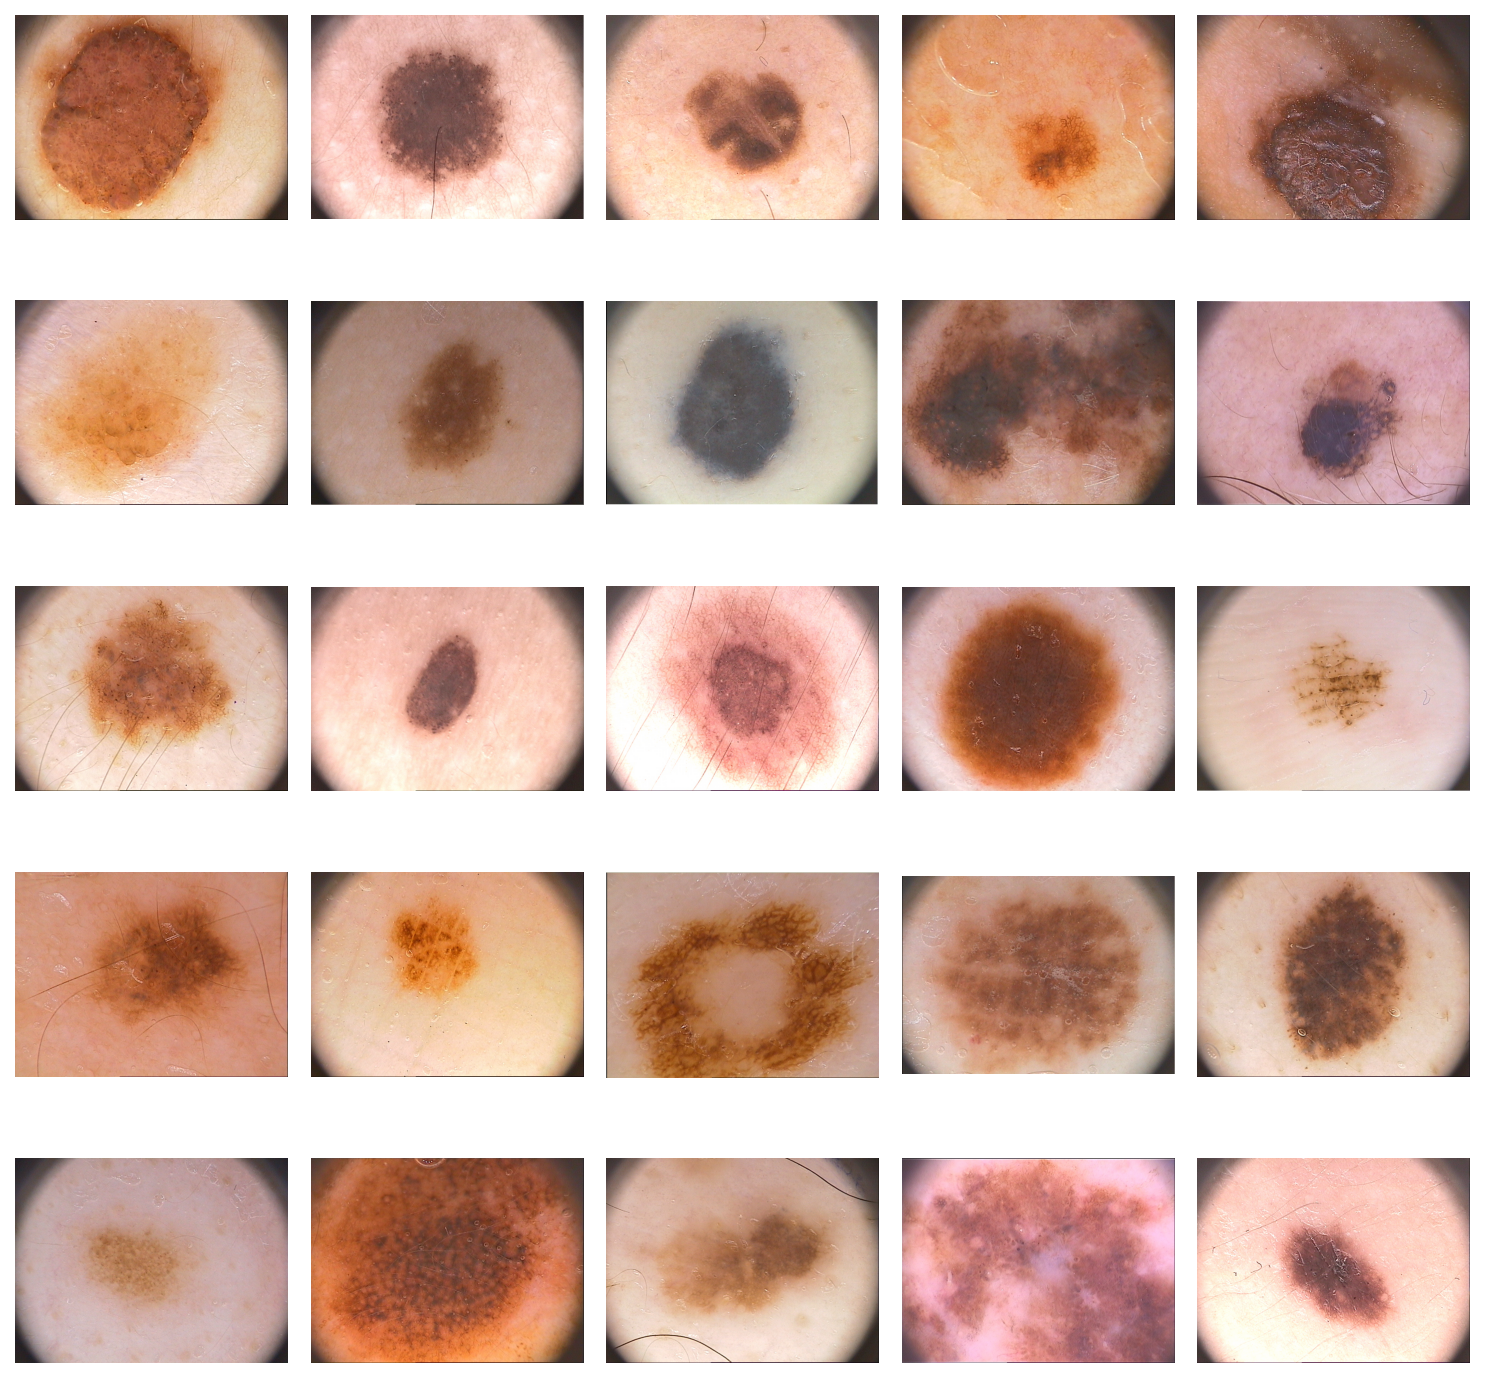

In [45]:
# Example usage:
visualize_dataset_grid(full_dataset, start_index=175)